In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

## 📂 Import Result ResNet152v2 Original Model

In [2]:
df_paper = pd.read_csv("/home/kannika/code/Result_ResNet152v2_MLorigin_USAI_unfreeze_conv3_block-conv5_block-R2_unbalanced_FieldTestset.csv")
print(df_paper.shape)
df_paper.head()

(807, 29)


,Unnamed: 0,index,Unnamed: 0.1,Case,FileName,Views,Label,Width,Height,X1,...,Path Full,Class,Sub_class_name,Sub_class,Path Crop,Path Crop_I7,Sub_Class_15AB,Views_,category,Prob
0,0,0,0,12215,12215_9.jpg,P42,Normal,800,600,219.6,...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort/12...,Normal,['Normal'],['Normal'],/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,Normal,FP-B,Normal,0.703299
1,1,1,1,12215,12215_8.jpg,P41,Normal,800,600,227.0,...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort/12...,Normal,['Normal'],['Normal'],/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,Normal,FP-B,Normal,0.999998
2,2,2,2,12215,12215_7.jpg,P52,Normal,800,600,290.0,...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort/12...,Normal,['Normal'],['Normal'],/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,Normal,FP-C,AB12,0.999840
3,3,3,3,12215,12215_6.jpg,P52,Normal,800,600,289.9,...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort/12...,Normal,['Normal'],['Normal'],/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,Normal,FP-C,AB12,0.999998
4,4,4,4,12215,12215_5.jpg,P61,Normal,800,600,236.7,...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort/12...,Normal,['Normal'],['Normal'],/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,Normal,FP-C,AB09,0.991682


Text(0.5, 21.5, 'Predicted label')

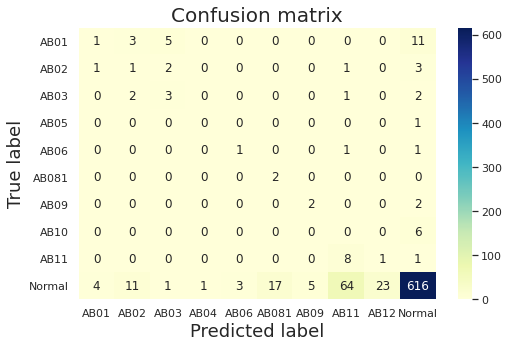

In [3]:
#create CF 
act = df_paper['Sub_Class_15AB'].array
pred = df_paper['category'].array

data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)

## 📂Import Result ResNet152v2 Unlearn - unfreeze_conv3_block-conv5_block (conv3_block-conv5_block & FC)

In [4]:
df_unlearn = pd.read_csv("/home/kannika/code/Result_ResNet152v2_MLunlearn_USAI_unfreeze_conv3_block-conv5_block-R2_unbalanced_FieldTestset.csv")
print(df_unlearn.shape)
df_unlearn.head()

(807, 29)


,Unnamed: 0,index,Unnamed: 0.1,Case,FileName,Views,Label,Width,Height,X1,...,Path Full,Class,Sub_class_name,Sub_class,Path Crop,Path Crop_I7,Sub_Class_15AB,Views_,category,Prob
0,0,0,0,12215,12215_9.jpg,P42,Normal,800,600,219.6,...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort/12...,Normal,['Normal'],['Normal'],/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,Normal,FP-B,Normal,0.998863
1,1,1,1,12215,12215_8.jpg,P41,Normal,800,600,227.0,...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort/12...,Normal,['Normal'],['Normal'],/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,Normal,FP-B,Normal,1.000000
2,2,2,2,12215,12215_7.jpg,P52,Normal,800,600,290.0,...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort/12...,Normal,['Normal'],['Normal'],/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,Normal,FP-C,Normal,0.868430
3,3,3,3,12215,12215_6.jpg,P52,Normal,800,600,289.9,...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort/12...,Normal,['Normal'],['Normal'],/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,Normal,FP-C,Normal,0.709664
4,4,4,4,12215,12215_5.jpg,P61,Normal,800,600,236.7,...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort/12...,Normal,['Normal'],['Normal'],/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,/media/tohn/SSD/ImageFromAzureDB_IsanCohort_cr...,Normal,FP-C,Normal,0.999986


In [5]:
import numpy as np
from sklearn.metrics import confusion_matrix
act = df_unlearn['Sub_Class_15AB'].array
pred = df_unlearn['category'].array

cmat = confusion_matrix(act, pred)
print('classifier accuracy = {}%'.format((100.*np.trace(cmat))/(np.sum(cmat))))

#Marking the Confusion Matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(act, pred))#performance

classifier accuracy = 87.98017348203221%
              precision    recall  f1-score   support

        AB01       0.22      0.10      0.14        20
        AB02       0.21      0.38      0.27         8
        AB03       0.38      0.38      0.38         8
        AB05       0.00      0.00      0.00         1
        AB06       1.00      0.33      0.50         3
       AB081       0.11      0.50      0.18         2
       AB082       0.00      0.00      0.00         0
        AB09       1.00      0.50      0.67         4
        AB10       0.00      0.00      0.00         6
        AB11       0.27      0.70      0.39        10
        AB12       0.00      0.00      0.00         0
      Normal       0.95      0.93      0.94       745

    accuracy                           0.88       807
   macro avg       0.35      0.32      0.29       807
weighted avg       0.90      0.88      0.89       807



/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kannika/miniconda3/envs/AI/lib/python3.6/site-packages/sklearn/metrics/_classification.py:1245: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/kan

Text(0.5, 21.5, 'Predicted label')

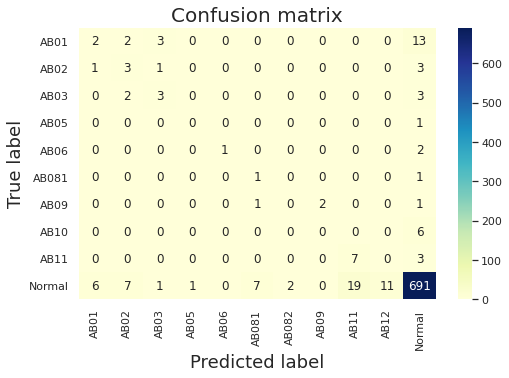

In [6]:
#create CF 
data = {'Actual': act,'Predicted' : pred,}
df = pd.DataFrame(data, columns=['Actual','Predicted'])
conf_mat = pd.crosstab(df['Actual'],df['Predicted'],rownames=['Actual'],colnames=['Predicted'])

#Confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(act, pred)

#plot Confusion matrix
import seaborn as sns
sns.set()
fig, ax = plt.subplots(figsize=(8, 5))

ax = sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlGnBu") #Blues,Oranges,Reds
ax.set_title('Confusion matrix',fontsize=20)
ax.set_ylabel('True label',fontsize=18)
ax.set_xlabel('Predicted label',fontsize=18)

##  ⚙️💡Evaluation

In [7]:
#เช็คคลาสใน Predicted
pred_class_paper = set(df_paper['category'])
print(len(pred_class_paper))
print(pred_class_paper)

pred_class_unlearn = set(df_unlearn['category'])
print(len(pred_class_unlearn))
print(pred_class_unlearn)

10
{'AB11', 'AB081', 'AB06', 'AB09', 'AB12', 'AB02', 'AB04', 'AB03', 'Normal', 'AB01'}
11
{'AB11', 'AB081', 'AB06', 'AB09', 'AB12', 'AB05', 'AB02', 'AB03', 'AB082', 'Normal', 'AB01'}


In [8]:
pred_paper = df_paper['category'].array
print(len(pred_paper))

pred_unlearn = df_unlearn['category'].array
print(len(pred_unlearn))

act = df_paper['Sub_Class_15AB'].array
print(len(act))

807
807
807


In [9]:
batch_size = 32
height = width = 456

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
      rescale=1./255,
      rotation_range=30,
      width_shift_range=0.2,
      height_shift_range=0.2,
      brightness_range=[0.5,1.5],
      shear_range=0.4,
      zoom_range=0.2,
      horizontal_flip=False,
      fill_mode='nearest')

train_generator = train_datagen.flow_from_dataframe(
        dataframe = df_paper,
        directory = None,
        x_col = 'Path Crop_I7',
        y_col = 'Sub_Class_15AB',
        target_size = (height, width),
        batch_size=batch_size,
        color_mode= 'rgb',
        class_mode='categorical')

#label
labels = (train_generator.class_indices)
labels = dict((v,k.replace("C","")) for k,v in labels.items())
print(labels)

Found 807 validated image filenames belonging to 10 classes.
{0: 'AB01', 1: 'AB02', 2: 'AB03', 3: 'AB05', 4: 'AB06', 5: 'AB081', 6: 'AB09', 7: 'AB10', 8: 'AB11', 9: 'Normal'}


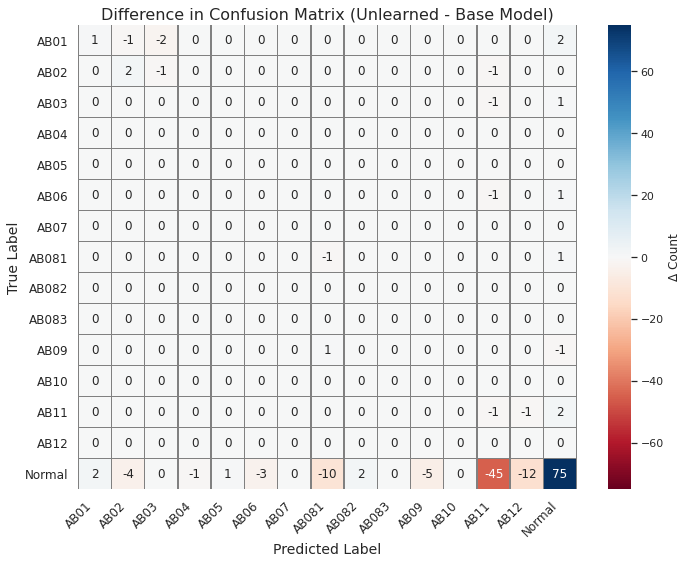

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Class labels ที่ต้องการให้เรียงแบบเดียวกันทั้ง 2 matrix
class_labels = ['AB01', 'AB02','AB03','AB04','AB05','AB06','AB07','AB081','AB082',
                'AB083','AB09','AB10','AB11','AB12','Normal']

# ดึงค่าจาก DataFrame
act = df_paper['Sub_Class_15AB']
pred_paper = df_paper['category']
pred_unlearn = df_unlearn['category']

# สร้าง confusion matrices โดยกำหนด class labels ชัดเจน
cm_base = confusion_matrix(act, pred_paper, labels=class_labels)
cm_unlearn = confusion_matrix(act, pred_unlearn, labels=class_labels)

# คำนวณความต่าง
cm_diff = cm_unlearn - cm_base

# หาค่าความต่างสูงสุด เพื่อนำไปตั้ง scale ที่สมมาตรรอบ 0
max_diff = np.max(np.abs(cm_diff))

# วาด heatmap
plt.figure(figsize=(10, 8))
ax = sns.heatmap(cm_diff, annot=True, fmt="d", cmap="RdBu", center=0,
                 vmin=-max_diff, vmax=max_diff,
                 xticklabels=class_labels, yticklabels=class_labels,
                 linewidths=0.5, linecolor='gray', cbar_kws={'label': 'Δ Count'})

ax.set_facecolor('white')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.title("Difference in Confusion Matrix (Unlearned - Base Model)", fontsize=16)
plt.tight_layout()
plt.show()

In [24]:
print(pd.crosstab(pd.Series(act, name="Actual"), pd.Series(pred_paper, name="Predicted Base")))
print(pd.crosstab(pd.Series(act, name="Actual"), pd.Series(pred_unlearn, name="Predicted Unlearn")))

Predicted Base  AB01  AB02  AB03  AB04  AB05  AB06  AB07  AB081  AB082  AB083  \
Actual                                                                          
AB01              74     0     0     0     0     0     0      0      0      0   
AB02               0    59     0     0     0     0     0      0      0      0   
AB03               0     0    19     0     0     0     0      0      0      0   
AB04               0     0     0    38     0     0     0      0      0      0   
AB05               0     0     0     0    29     0     0      0      0      0   
AB06               0     0     0     0     0    21     0      0      0      0   
AB07               0     0     0     0     0     0    21      0      0      0   
AB081              0     0     0     0     0     0     0     32      0      0   
AB082              0     0     0     0     0     0     0      0     28      0   
AB083              0     0     0     0     0     0     0      0      0     11   
AB09               0     0  

In [23]:
852-849

3

In [17]:
cm_base

array([[ 74,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,  59,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,  19,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,  38,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  29,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  21,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  21,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  32,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  28,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  11,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  26,   0,   0,
       

In [18]:
cm_unlearn

array([[ 49,  10,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  15],
       [ 10,  33,   9,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
          0,   6],
       [  0,   6,  13,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,  23,   0,   0,   1,   1,   0,   0,   0,   0,   0,
          1,  12],
       [  0,   0,   0,   0,  21,   1,   0,   0,   0,   0,   0,   0,   0,
          0,   7],
       [  0,   0,   0,   0,   0,  11,   3,   0,   0,   0,   0,   0,   0,
          0,   7],
       [  0,   0,   0,   0,   0,   0,  11,   0,   0,   0,   0,   0,   0,
          0,  10],
       [  2,   1,   0,   0,   0,   0,   0,  20,   0,   1,   0,   0,   1,
          0,   7],
       [  0,   0,   0,   0,   1,   1,   0,   1,  16,   3,   2,   0,   1,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   1,   9,   0,   0,   0,
          0,   1],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  21,   2,   1,
       

In [21]:
cm_diff

array([[-25,  10,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  15],
       [ 10, -26,   9,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
          0,   6],
       [  0,   6,  -6,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0, -15,   0,   0,   1,   1,   0,   0,   0,   0,   0,
          1,  12],
       [  0,   0,   0,   0,  -8,   1,   0,   0,   0,   0,   0,   0,   0,
          0,   7],
       [  0,   0,   0,   0,   0, -10,   3,   0,   0,   0,   0,   0,   0,
          0,   7],
       [  0,   0,   0,   0,   0,   0, -10,   0,   0,   0,   0,   0,   0,
          0,  10],
       [  2,   1,   0,   0,   0,   0,   0, -12,   0,   1,   0,   0,   1,
          0,   7],
       [  0,   0,   0,   0,   1,   1,   0,   1, -12,   3,   2,   0,   1,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   1,  -2,   0,   0,   0,
          0,   1],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  -5,   2,   1,
       

In [9]:
pred_paper

<PandasArray>
[  'AB01',   'AB01',   'AB01',   'AB01',   'AB01',   'AB02',   'AB02',
   'AB02',   'AB02',   'AB04',
 ...
 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal',
 'Normal', 'Normal', 'Normal']
Length: 1312, dtype: object

In [10]:
pred_unlearn

<PandasArray>
['Normal',   'AB01',   'AB01',   'AB01',   'AB02', 'Normal',   'AB02',
   'AB02',   'AB03',   'AB04',
 ...
 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal',
 'Normal', 'Normal', 'Normal']
Length: 1312, dtype: object